In [108]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import torch
import numpy as np
from pathlib import Path

from eval_fluent_deeponet import (
    InterfaceIterationConfig,
    iterative_unknown_interface_inference,
    simulated_annealing_unknown_interface_inference,
    make_plot_dict_from_iterative_result,
    select_sample_indices_by_case_id,
    infer_edge_layout,
)
from fluent_deeponet import DeepONet, FeatureNormalizer
from deeponet_fluent_dataset import build_fluent_deeponet_dataset

from plot import plot_prediction_imshow_from_points

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
device = torch.device("cuda:2")
ckpt_path = Path("results") / "060826_2" / "checkpoint.pt"
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

model = DeepONet(**ckpt["model_config"]).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

y_normalizer = FeatureNormalizer.from_state_dict(ckpt["y_normalizer"]).to(device)
local_aspect_mean = float(ckpt["local_aspect_mean"])
local_aspect_std = float(ckpt["local_aspect_std"])


In [121]:
FIELD_MAP = {"pressure": "SV_P", "u": "SV_U", "v": "SV_V"}
ROOT_DIR = Path("/home/hantianl/Documents/PIDIF/")
DATASET_NAME = "channel_water"

def case_paths(ch):
    return {
        "design": ROOT_DIR / f"2d_geometry_specs/{DATASET_NAME}/{ch}.json",
        "mesh": ROOT_DIR / f"runs_2d/{DATASET_NAME}/{ch}/{ch}.msh.h5",
        "dat": ROOT_DIR / f"runs_2d/{DATASET_NAME}/{ch}/case2d.dat.h5",
    }

available_cases = [
    ch.name for ch in (ROOT_DIR / "runs_2d" / DATASET_NAME).iterdir()
    if all(case_paths(ch.name)[k].exists() for k in ("design", "mesh", "dat"))
]
case_files = {ch: case_paths(ch) for ch in available_cases}

bc_kwargs = {
    "inlet_v": 0.0,
    "outlet_p": 0.0,
    "wall_u": 0.0,
    "wall_v": 0.0,
}

TEST_CH = ["channel_03"]
rng = np.random.default_rng(0)

test_data = build_fluent_deeponet_dataset(
    case_files=case_files,
    case_ids=TEST_CH,
    n_subdomains="adaptive",
    n_interface_points=256,
    n_boundary_points=256,
    interface_placement="control_points",
    interface_jitter=0,
    field_map=FIELD_MAP,
    bc_kwargs=bc_kwargs,
    keep_raw_case_data=False,
    rng=rng,
)

sample_test_ids = select_sample_indices_by_case_id(test_data, case_id=TEST_CH[0])

Setting n_realizations to 1 for control points interface placement with adaptive n_subdomains
Processing case channel_03 realization=0 (n_subdomains=10)


In [ ]:
config = InterfaceIterationConfig(
    max_iter=10,
    tol=1.0e-6,
    mse_mode="normalized",
    relaxation=1,
    random_seed=0,
    init_mode="fixed_value",
    init_std_scale=1.0,
    init_value=[0, 0, 0],
    init_noise_std=0,
    reduce_mode="dct",
    query_batch_size=32768,
    sample_batch_size=20,
    preserve_wall_corners=False,
    verbose=True,
)

test_result = iterative_unknown_interface_inference(
    model=model,
    samples=[test_data["samples"][i] for i in sample_test_ids],
    branch_channel_names=test_data["branch_channel_names"],
    device=device,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    config=config,
)

print("Converged:", test_result["converged"], "iterations:", test_result["n_iter"])
print("Final prediction samples:", len(test_result["pred_samples"]))


iter=0001 | interface MSE max=3.621617e-01, mean=1.271188e-01 | converged=0/19


iter=0002 | interface MSE max=9.720060e-02, mean=8.852364e-02 | converged=0/19
iter=0003 | interface MSE max=1.204379e-01, mean=1.032613e-01 | converged=0/19
iter=0004 | interface MSE max=1.271425e-01, mean=1.050989e-01 | converged=0/19
iter=0005 | interface MSE max=1.332442e-01, mean=1.071616e-01 | converged=0/19
iter=0006 | interface MSE max=1.399189e-01, mean=1.099188e-01 | converged=0/19
iter=0007 | interface MSE max=1.471938e-01, mean=1.132069e-01 | converged=0/19
iter=0008 | interface MSE max=1.551195e-01, mean=1.169514e-01 | converged=0/19
iter=0009 | interface MSE max=1.637534e-01, mean=1.211213e-01 | converged=0/19
iter=0010 | interface MSE max=1.731889e-01, mean=1.257077e-01 | converged=0/19
Converged: False iterations: 10
Final prediction samples: 20


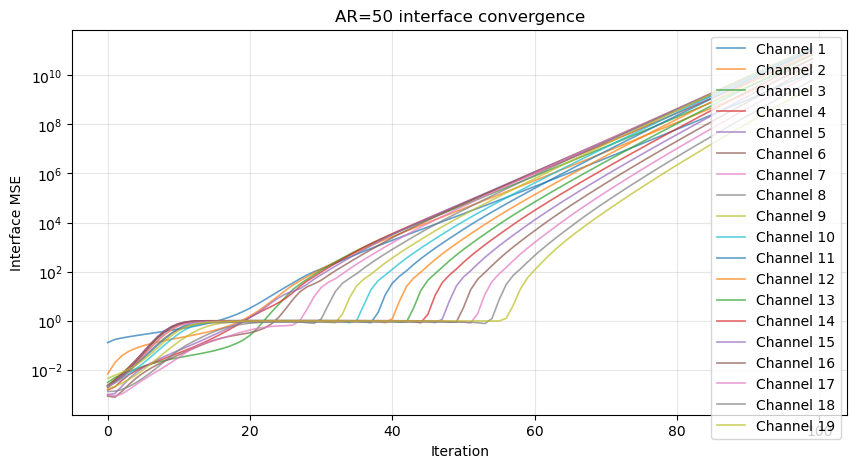

In [311]:
mse_history = test_result["interface_mse_history"]
plt.figure(figsize=(10, 5))
for k in range(mse_history.shape[1]):
    plt.plot(mse_history[:, k], alpha=0.7, linewidth=1.2, label=f"Channel {k+1}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Interface MSE")
plt.title(f"AR={TEST_AR} interface convergence")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

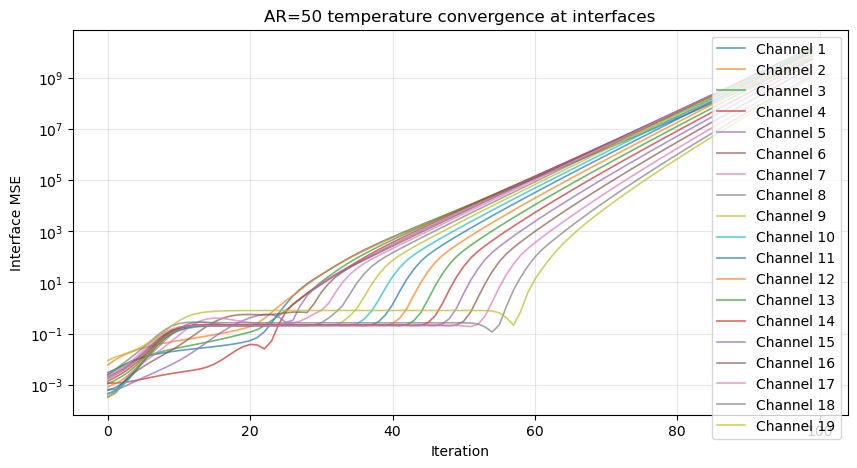

In [312]:
channel_history = test_result["interface_mse_by_channel_history"]
plt.figure(figsize=(10, 5))
for k in range(channel_history.shape[1]):
    plt.plot(channel_history[:, k, 1], alpha=0.7, linewidth=1.2, label=f"Channel {k+1}")
plt.yscale("log")
plt.xlabel("Iteration")
plt.ylabel("Interface MSE")
plt.title(f"AR={TEST_AR} temperature convergence at interfaces")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

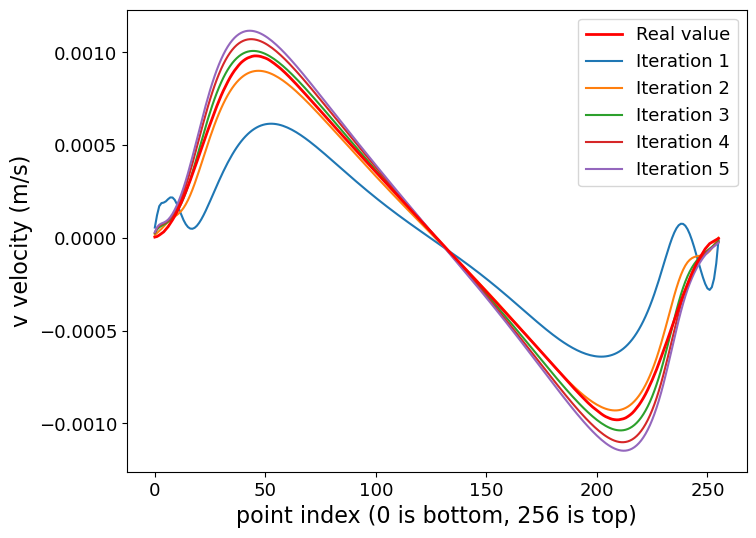

In [425]:
int_id = 1
val_id = 3
range_i = (0, 5)
br = test_data["samples"][sample_test_ids[int_id]]["branch"]
real_t = br[(br[:, 0] == 0) & (br[:, 3] == 1)][:, val_id + 4]
t_history = test_result["interface_left_values_history"][:, int_id, :, val_id]

plt.figure(figsize=(8, 6))
plt.plot(real_t, zorder=10, lw=2, label="Real value", c="r")
for i in range(range_i[0], range_i[1]):
    plt.plot(t_history[i, :], label=f"Iteration {i+1}")
    
plt.xlabel("point index (0 is bottom, 256 is top)", fontsize=16)
plt.ylabel("v velocity (m/s)", fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
leg = plt.legend(loc=1, fontsize=13)
leg.set_zorder(20)
plt.show()


In [185]:
# Simulated annealing interface solve: minimize predicted interface mismatch only.
# This does not add smoothness/range/truth penalties.

sa_config = InterfaceIterationConfig(
    max_iter=500000,
    tol=1.0e-6,
    mse_mode="normalized",
    relaxation=1.0,
    random_seed=0,
    init_mode="fixed",
    init_std_scale=1.0,
    init_value=[0, 0, 0],
    init_noise_std=0.0,
    reduce_mode="dct",
    query_batch_size=32768,
    sample_batch_size=20,
    preserve_wall_corners=False,
    verbose=True,
)

test_result_sa = simulated_annealing_unknown_interface_inference(
    model=model,
    samples=[test_data["samples"][i] for i in sample_test_ids],
    branch_channel_names=test_data["branch_channel_names"],
    device=device,
    y_normalizer=y_normalizer,
    local_aspect_mean=local_aspect_mean,
    local_aspect_std=local_aspect_std,
    config=sa_config,
    temperature0=None,          # None -> 0.1 * initial energy
    temperature_min=1.0e-8,
    proposal_sigma0=0.05,
    proposal_sigma_min=0.001,
    proposal_location="channel",
    sample_mode="fixed",
    objective="mean",
    verbose_every=100,
)

print("SA converged:", test_result_sa["converged"], "steps:", test_result_sa["n_iter"])
print("Best energy:", test_result_sa["best_energy"])
print("Best max MSE:", np.max(test_result_sa["best_interface_mse_history"][-1]))

Initial energy: 6.113047e-01
Initializing temperature
Initial temperature: 5.173708e-02
sa_step=00100 | E=8.053400e-01 | best_E=6.113047e-01 | max_mse=1.331041e+00 | mean_mse=8.053400e-01 | best_max_mse=1.207040e+00 | T=5.158e-02 | sigma=4.996e-02 | accepted=True
sa_step=00200 | E=7.637279e-01 | best_E=6.113047e-01 | max_mse=1.135817e+00 | mean_mse=7.637279e-01 | best_max_mse=1.207040e+00 | T=5.142e-02 | sigma=4.992e-02 | accepted=True
sa_step=00300 | E=8.416919e-01 | best_E=6.113047e-01 | max_mse=1.406953e+00 | mean_mse=8.416919e-01 | best_max_mse=1.207040e+00 | T=5.126e-02 | sigma=4.988e-02 | accepted=True
sa_step=00400 | E=6.566996e-01 | best_E=6.113047e-01 | max_mse=9.642132e-01 | mean_mse=6.566995e-01 | best_max_mse=1.207040e+00 | T=5.110e-02 | sigma=4.984e-02 | accepted=False
sa_step=00500 | E=6.967688e-01 | best_E=6.113047e-01 | max_mse=1.183443e+00 | mean_mse=6.967688e-01 | best_max_mse=1.207040e+00 | T=5.094e-02 | sigma=4.980e-02 | accepted=False
sa_step=00600 | E=8.020130e-01

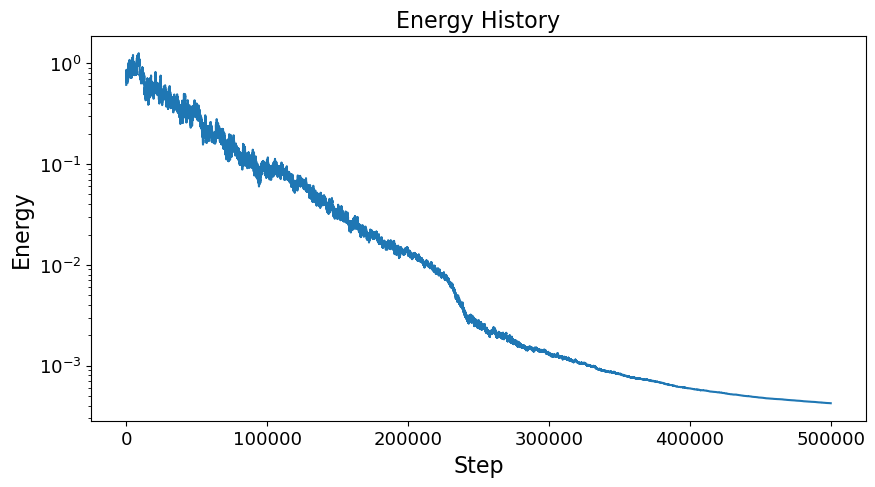

In [186]:
plt.figure(figsize=(10, 5))
plt.plot(test_result_sa["energy_history"])
plt.xlabel("Step", fontsize=16)
plt.ylabel("Energy", fontsize=16)
plt.title("Energy History", fontsize=16)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.yscale("log")
plt.show()

In [213]:
pred = np.concat(test_result_sa["pred_samples"], axis=0)
truth = np.concat([test_data["samples"][i]["target"] for i in range(len(test_data["samples"]))], axis=0)
err = np.abs(pred - truth)

rel_l2 = np.linalg.norm(err, axis=0) / np.linalg.norm(truth, axis=0)
print(rel_l2)


[0.31687158 0.03717881 0.6334756 ]


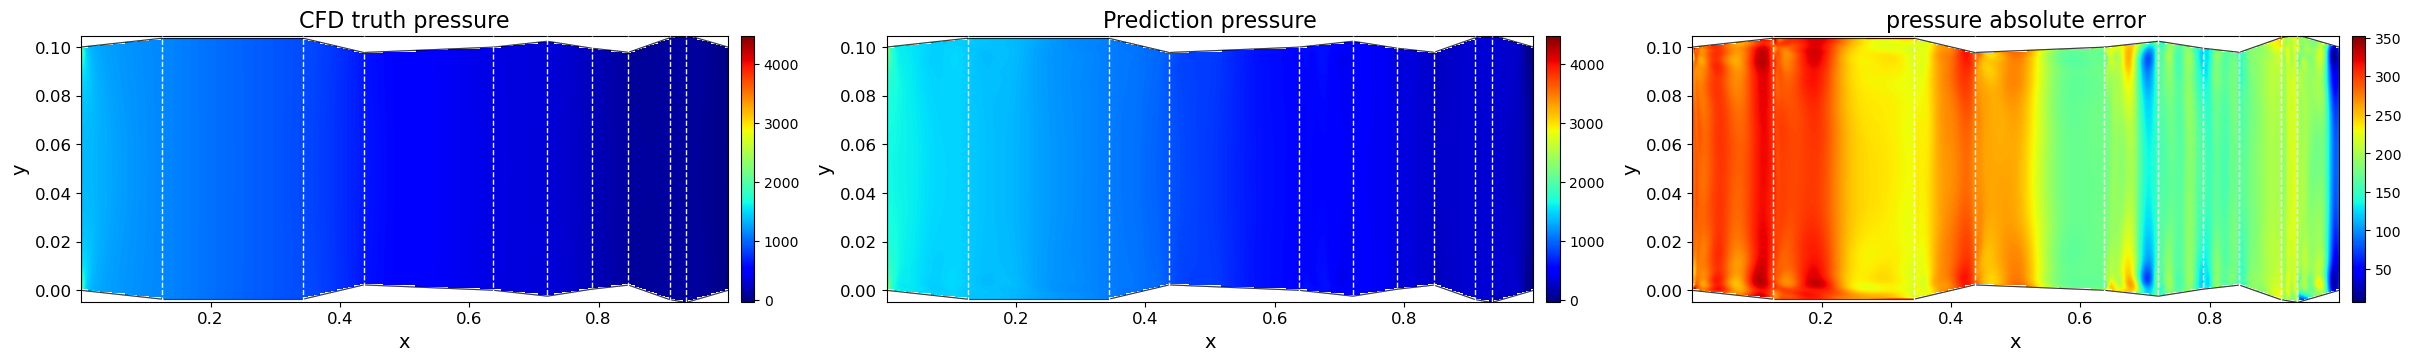

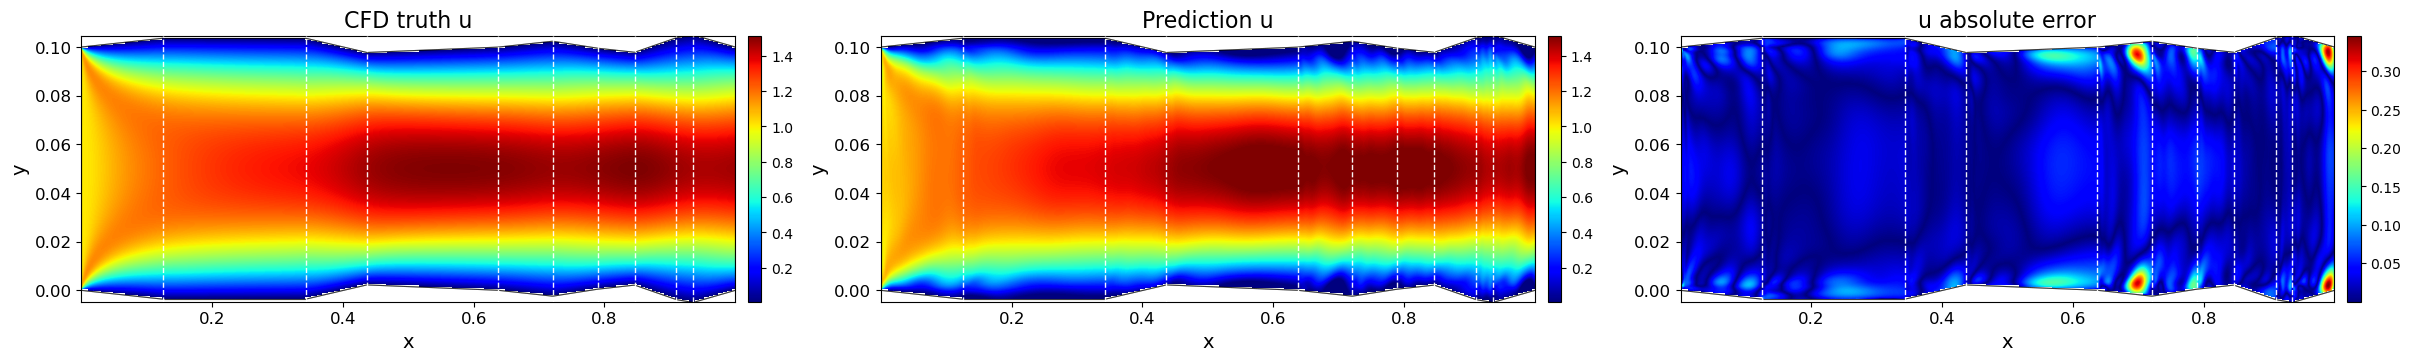

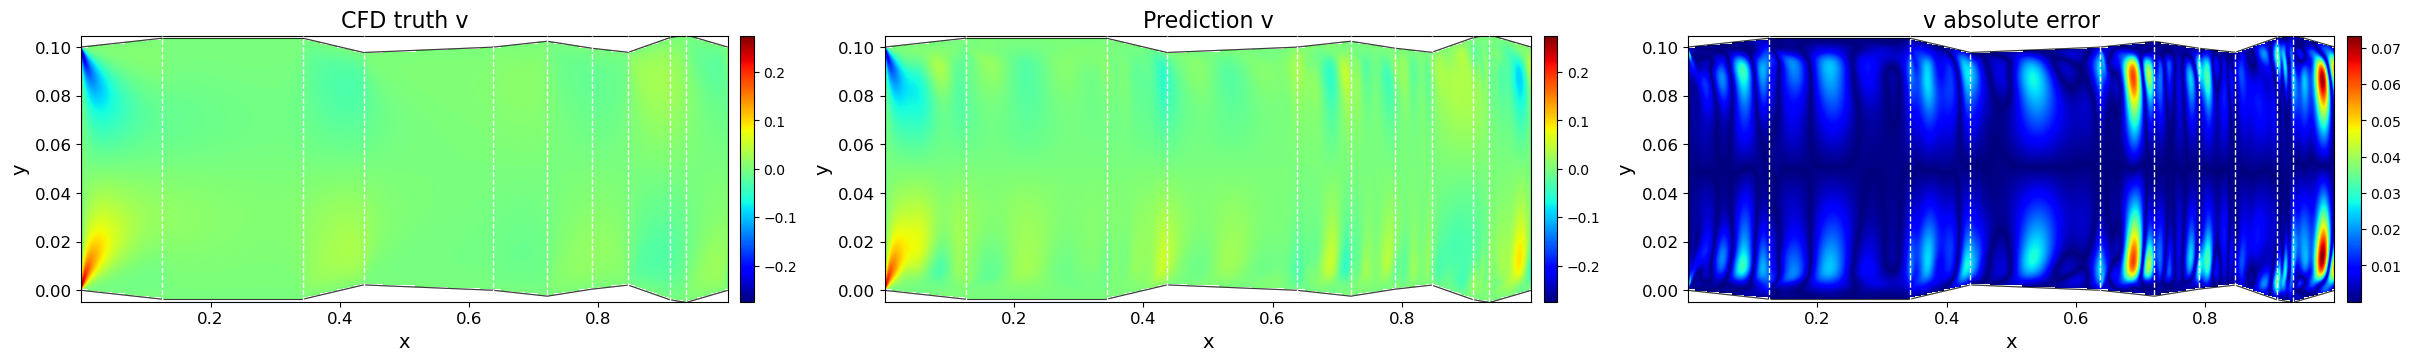

In [187]:
p_plot = make_plot_dict_from_iterative_result(
    result=test_result_sa,
    data=test_data,
    sample_indices=sample_test_ids,
)

output_channel_names = test_data["output_channel_names"]
for field_name in output_channel_names:
    field_idx = output_channel_names.index(field_name)

    plot_prediction_imshow_from_points(
        x=p_plot["x"],
        y=p_plot["y"],
        pred=p_plot["pred"],
        truth=p_plot["truth"],
        field_name=field_name,
        field_idx=field_idx,
        n_y_plot=200,
        metadata=test_data["metadata"],
        mesh_h5=case_files[TEST_CH[0]]["mesh"],
    )

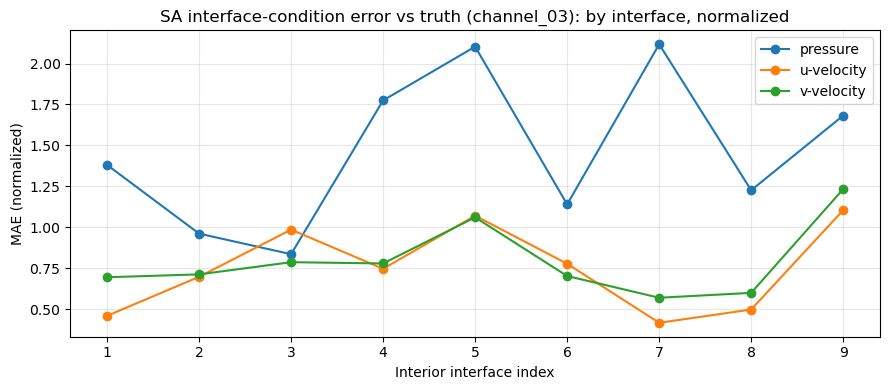

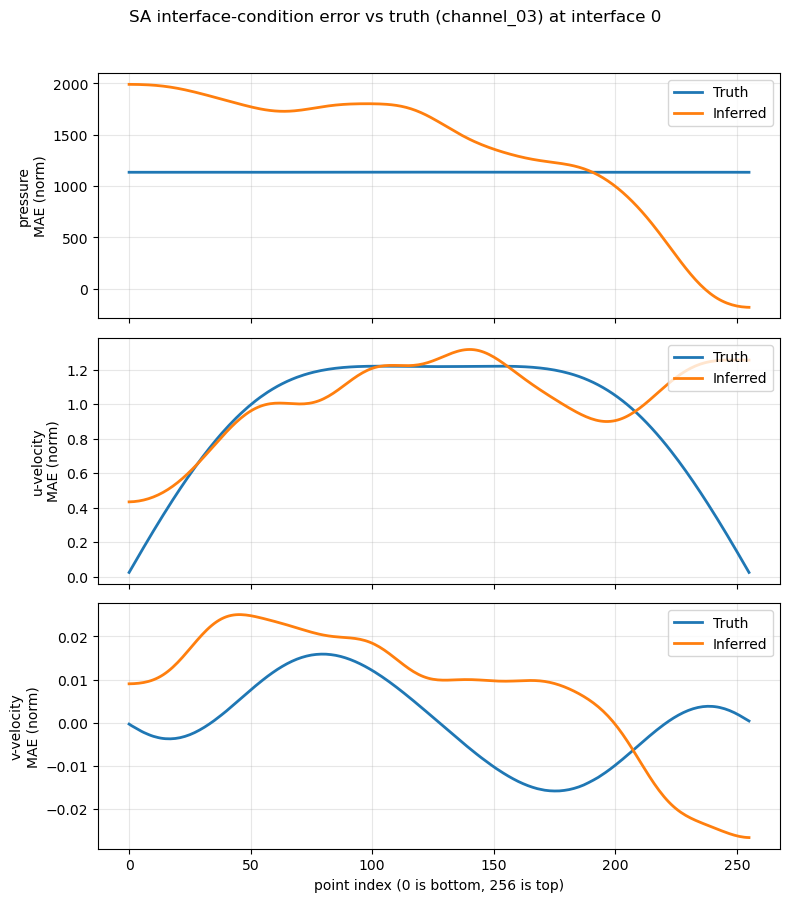

Global MAE per channel normalized:
                pressure: 1.469181e+00
              u-velocity: 7.510017e-01
              v-velocity: 7.935011e-01
Overall MAE (all interfaces, points, channels): 1.0045613050460815


In [188]:
true_branch = np.stack([test_data["samples"][i]["branch"] for i in sample_test_ids], axis=0).astype(np.float32)
infer_branch = np.asarray(test_result_sa["branch_final"], dtype=np.float32)

layout = infer_edge_layout(true_branch[0], test_data["branch_channel_names"])
channel_labels = ["pressure", "u-velocity", "v-velocity"]

n_sub = true_branch.shape[0]
value_idx = layout.value_channels

true_interfaces = []
infer_interfaces = []
for interface_id in range(1, n_sub):
    i_right = infer_branch[interface_id - 1][np.ix_(layout.right, value_idx)]
    i_left = infer_branch[interface_id][np.ix_(layout.left, value_idx)]

    true_interfaces.append(true_branch[interface_id][np.ix_(layout.left, value_idx)])
    infer_interfaces.append(0.5 * (i_right + i_left))

true_interfaces = np.stack(true_interfaces, axis=0)   # (n_if, n_y, n_ch)
infer_interfaces = np.stack(infer_interfaces, axis=0) # (n_if, n_y, n_ch)

err = infer_interfaces - true_interfaces

yn_mean = y_normalizer.mean.detach().cpu().numpy().astype(np.float32).reshape(1, 1, -1)
yn_std = y_normalizer.std.detach().cpu().numpy().astype(np.float32).reshape(1, 1, -1)
yn_std = np.maximum(yn_std, 1.0e-12)

true_interfaces_norm = (true_interfaces - yn_mean) / yn_std
infer_interfaces_norm = (infer_interfaces - yn_mean) / yn_std
err_norm = infer_interfaces_norm - true_interfaces_norm
abs_err_norm = np.abs(err_norm)

# Figure 1: MAE by interface (line per channel)
mae_if_ch = abs_err_norm.mean(axis=1)  # (n_if, n_ch)
plt.figure(figsize=(9, 4))
for ch in range(mae_if_ch.shape[1]):
    plt.plot(np.arange(1, mae_if_ch.shape[0] + 1), mae_if_ch[:, ch], marker='o', label=channel_labels[ch])
plt.xlabel("Interior interface index")
plt.ylabel("MAE (normalized)")
plt.title(f"SA interface-condition error vs truth ({TEST_CH[0]}): by interface, normalized")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Figure 2: Error along y at given interface
int_eval = 0
fig, axes = plt.subplots(3, 1, figsize=(8, 2.2 * 4), sharex=True)
for ch, ax in enumerate(axes):
    ax.plot(true_interfaces[int_eval, :, ch], lw=2, label="Truth")
    ax.plot(infer_interfaces[int_eval, :, ch], lw=2, label="Inferred")
    ax.set_ylabel(f"{channel_labels[ch]}\nMAE (norm)")
    ax.legend(loc=1)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel("point index (0 is bottom, 256 is top)")
fig.suptitle(f"SA interface-condition error vs truth ({TEST_CH[0]}) at interface {int_eval}", y=1.02)
fig.tight_layout()
plt.show()

global_mae_ch = abs_err_norm.mean(axis=(0, 1))
print("Global MAE per channel normalized:")
for label, val in zip(channel_labels, global_mae_ch):
    print(f"  {label:>22s}: {val:.6e}")
print("Overall MAE (all interfaces, points, channels):", float(abs_err_norm.mean()))

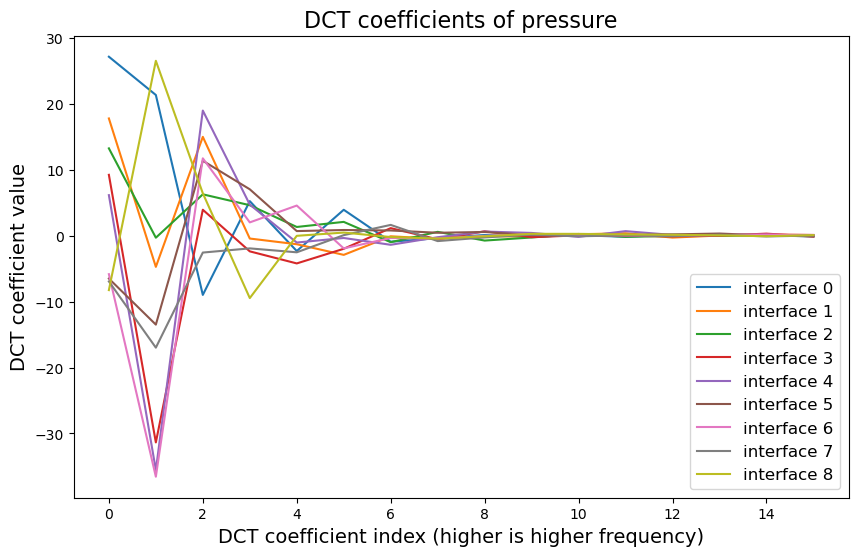

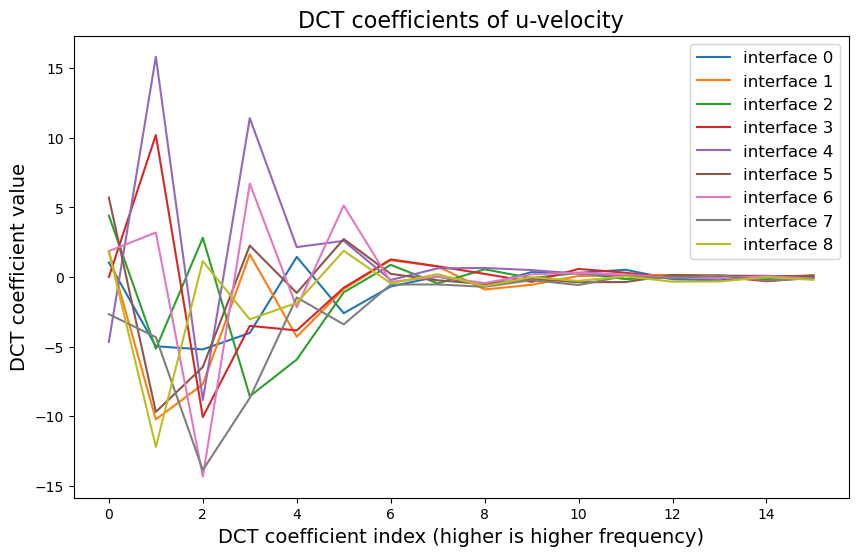

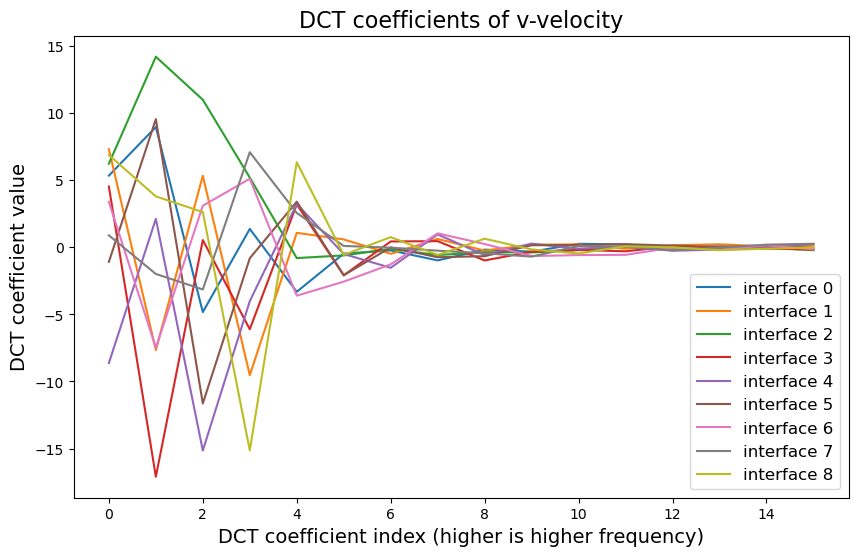

In [189]:
best_z = test_result_sa["best_z"]
assert isinstance(best_z, np.ndarray)
channels = ["pressure", "u-velocity", "v-velocity"]
for c in range(best_z.shape[2]):
    plt.figure(figsize=(10, 6))
    for i in range(best_z.shape[0]):
        plt.plot(best_z[i, :, c], label=f"interface {i}")
    plt.xlabel("DCT coefficient index (higher is higher frequency)", fontsize=14)
    plt.ylabel("DCT coefficient value", fontsize=14)
    plt.legend(fontsize=12)
    plt.title(f"DCT coefficients of {channels[c]}", fontsize=16)
    plt.show()